<a href="https://colab.research.google.com/github/ojaspaul123/ML-Experiments/blob/main/ML_Projects/Customer%20Segmentation/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
%%markdown
---
Loading and Cleaning the Dataset

---
Loading and Cleaning the Dataset


In [26]:
from google.colab import files
uploaded = files.upload()
df = pd.read_excel('Online Retail.xlsx')
df.head()

Saving Online Retail.xlsx to Online Retail (5).xlsx


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [27]:
df.shape

(541909, 8)

In [28]:
df.dropna(inplace=True)
df.reset_index(inplace = True,drop = True)


In [29]:
df.shape

(406829, 8)

In [30]:
new_df = df.copy()

In [31]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406829 entries, 0 to 406828
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 24.8+ MB


In [32]:
%%markdown
---
Data Cleaning and Preprocessing

---
Data Cleaning and Preprocessing


In [33]:
new_df = new_df.dropna(subset=['CustomerID'])
new_df = new_df[~new_df['InvoiceNo'].astype(str).str.startswith('C')]
new_df= new_df[new_df['Quantity'] > 0]
new_df = new_df[new_df["UnitPrice"] > 0]
new_df['TotalAmount'] = new_df['Quantity'] * new_df['UnitPrice']

In [34]:
new_df.shape

(397884, 9)

In [35]:
%%markdown
---
Exploratory Data Analysis (EDA)

---
Exploratory Data Analysis (EDA)


In [36]:
new_df['Country'].value_counts().head(10)

,count
Country,
United Kingdom,354321
Germany,9040
France,8341
EIRE,7236
Spain,2484
Netherlands,2359
Belgium,2031
Switzerland,1841
Portugal,1462


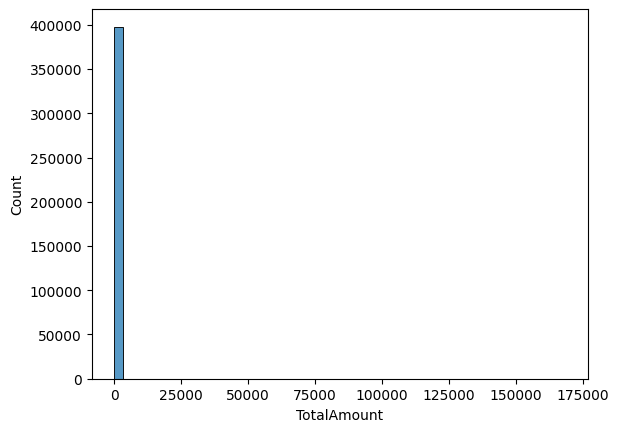

In [37]:
sns.histplot(new_df['TotalAmount'],bins = 50)
plt.show()

In [38]:
new_df['InvoiceDate'] = pd.to_datetime(new_df['InvoiceDate'])
snapshot_date = new_df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [39]:
rfm = new_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


In [40]:
rfm_log = np.log1p(rfm)

In [44]:
rfm_log

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,5.789960,0.693147,11.253955
12347.0,1.098612,2.079442,8.368925
12348.0,4.330733,1.609438,7.494564
12349.0,2.995732,0.693147,7.472245
12350.0,5.739793,0.693147,5.815324
...,...,...,...
18280.0,5.631212,0.693147,5.201806
18281.0,5.204007,0.693147,4.404522
18282.0,2.197225,1.098612,5.187665


In [41]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

In [43]:
rfm_scaled

array([[ 1.46199281, -0.95521426,  3.70622476],
       [-2.03873442,  1.07442519,  1.41184341],
       [ 0.37310424,  0.38630445,  0.7164889 ],
       ...,
       [-1.21893976, -0.36158278, -1.11812113],
       [-1.65755161,  2.17800394,  0.83829669],
       [-0.03473174,  0.05960547,  0.73400231]])

In [45]:
%%markdown
---
Find Best Number of Clusters

---
Find Best Number of Clusters


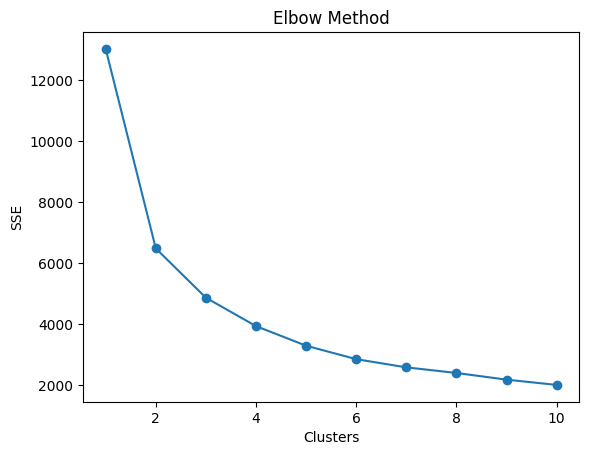

In [42]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
sse = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_scaled)
    sse.append(km.inertia_)

plt.plot(range(1,11), sse, marker='o')
plt.xlabel("Clusters")
plt.ylabel("SSE")
plt.title("Elbow Method")
plt.show()

In [46]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [47]:
cluster_summary = rfm.groupby('Cluster').mean()

print(cluster_summary)

            Recency  Frequency     Monetary
Cluster                                    
0         18.124253   2.148148   551.819534
1         12.131285  13.713687  8074.266872
2         71.084399   4.083546  1802.829005
3        182.496898   1.318238   343.450032


In [51]:
%%markdown
---
Evaluate the clustering performance

---
Evaluate the clustering performance


In [48]:
score = silhouette_score(rfm_scaled, rfm['Cluster'])

print(score)

0.3371343622222519


In [50]:
%%markdown
---
Visualize the clusters

---
Visualize the clusters


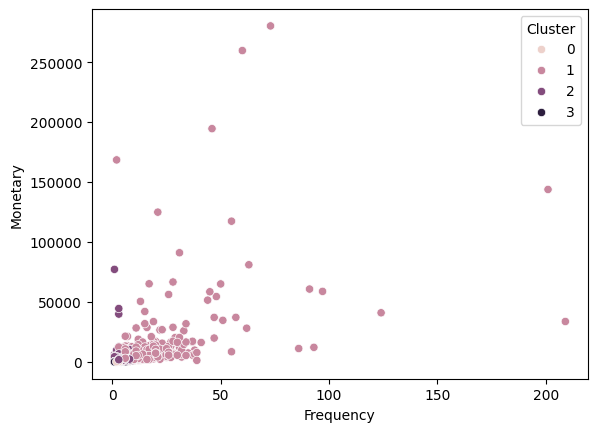

In [49]:
sns.scatterplot(
    x=rfm['Frequency'],
    y=rfm['Monetary'],
    hue=rfm['Cluster']
)

plt.show()

In [52]:
%%markdown
---
Save Kmeans For Future Inference

---
Save Kmeans For Future Inference


In [53]:
import pickle
pickle.dump(kmeans,open("kmeans.pkl",'wb'))

In [54]:
kmeans = pickle.load(open("kmeans.pkl",'rb'))

In [55]:
# Example new customer
new_customer = pd.DataFrame({
    'Recency': [20],
    'Frequency': [5],
    'Monetary': [1200]
})

# Apply same log transformation
new_customer_log = np.log1p(new_customer)

# Apply trained scaler
new_customer_scaled = scaler.transform(new_customer_log)

# Predict cluster
predicted_cluster = kmeans.predict(new_customer_scaled)

print("Predicted Cluster:", predicted_cluster[0])

Predicted Cluster: 2


In [56]:
test1 = pd.DataFrame({
    'Recency': [15],
    'Frequency': [10],
    'Monetary': [5000]
})

# Preprocessing
test1_log = np.log1p(test1)

test1_scaled = scaler.transform(test1_log)

# Predict cluster
test1_cluster = kmeans.predict(test1_scaled)

print("test1 Cluster:", test1_cluster[0])

test1 Cluster: 1


In [57]:
test2 = pd.DataFrame({
    'Recency': [200],
    'Frequency': [1],
    'Monetary': [80]
})

# Preprocessing
test2_log = np.log1p(test2)

test2_scaled = scaler.transform(test2_log)

# Predict cluster
test2_cluster = kmeans.predict(test2_scaled)

print("test2 Cluster:", test2_cluster[0])

test2 Cluster: 3
